#                                          DV Assignment 2  Netflix Data-Analysis
###                                                                       Name: Avani singh
###                                                                        Batch:BCADS 12
###                                                                        University Roll_no: 1250258153

In [1]:
import pandas as pd
net=pd.read_csv("netflix.csv")
net

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [2]:
net.shape

(8807, 12)

In [3]:
net.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [4]:
net.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [5]:
net.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [6]:
net["director"].fillna("Unknown",inplace=True)

In [7]:
net["cast"].fillna("Not Available",inplace=True)

In [8]:
net["country"].fillna("Unknown",inplace=True)

In [9]:
net["date_added"].fillna("NaT",inplace=True)

In [10]:
net["rating"].fillna("Not Rated",inplace=True)

In [11]:
net["director"].isnull().sum()

np.int64(0)

In [12]:
net["duration"].fillna(1,inplace=True)

In [13]:
net.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

# 1. What is the ratio of Movies vs TV Shows on Netflix? 

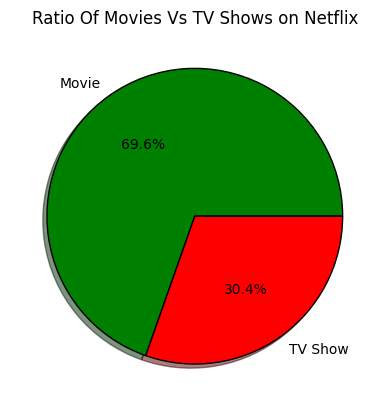

In [44]:
ratio_movie=net["type"].value_counts()
import matplotlib.pyplot as plt
plt.pie(x=ratio_movie,labels=ratio_movie.index,autopct="%1.1f%%",colors=["green","red"],shadow=True,wedgeprops={"edgecolor":"black"})
plt.title("Ratio Of Movies Vs TV Shows on Netflix")
plt.show()

Insight:
Movies vs. TV Shows Ratio: The platform is significantly tilted towards cinematic content. Out of 8,807 total titles, there are 69% Movies compared to 30% TV Shows. This indicates a historical priority on high-volume movie acquisitions, though the engagement metrics often favor the recurring nature of shows.

# 2. Which genres are most popular on Netflix globally? 

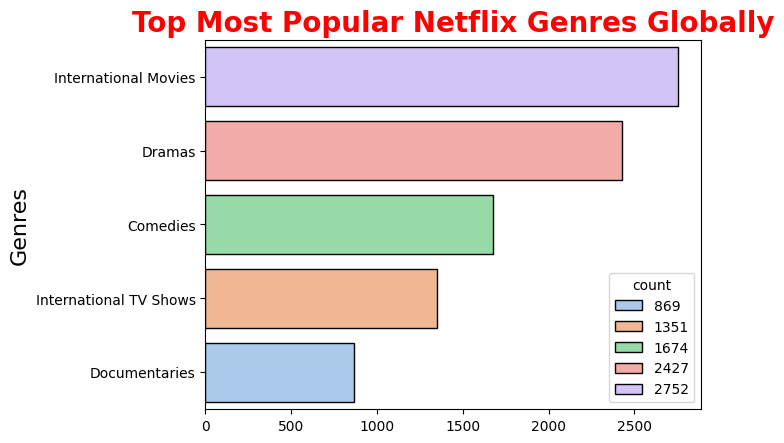

In [15]:
import matplotlib.pyplot as plt
import seaborn as sb
genres=net["listed_in"].str.split(",").explode().str.strip()
top_genres=genres.value_counts().sort_values(ascending=False).head()
top_genres
sb.barplot(x=top_genres.values,y=top_genres.index,hue=top_genres,palette="pastel",edgecolor="black")
plt.title("Top Most Popular Netflix Genres Globally",fontsize=20,color="red",fontweight="bold",loc="center")
plt.ylabel("Genres",fontsize=16)
plt.show()

insights:
Across the globe, international movies, dramas, and comedies are the most popular genres. This shows that audiences really connect with stories that feel local and emotionally relatable, highlighting a clear direction for future content acquisition

In [16]:
net["release_year"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 8807 entries, 0 to 8806
Series name: release_year
Non-Null Count  Dtype
--------------  -----
8807 non-null   int64
dtypes: int64(1)
memory usage: 68.9 KB


In [17]:
net.groupby("release_year").count()

,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
release_year,,,,,,,,,,,
1925,1,1,1,1,1,1,1,1,1,1,1
1942,2,2,2,2,2,2,2,2,2,2,2
1943,3,3,3,3,3,3,3,3,3,3,3
1944,3,3,3,3,3,3,3,3,3,3,3
1945,4,4,4,4,4,4,4,4,4,4,4
...,...,...,...,...,...,...,...,...,...,...,...
2017,1032,1032,1032,1032,1032,1032,1032,1032,1032,1032,1032
2018,1147,1147,1147,1147,1147,1147,1147,1147,1147,1147,1147
2019,1030,1030,1030,1030,1030,1030,1030,1030,1030,1030,1030


# 3. Which years saw the highest release of content on Netflix? 

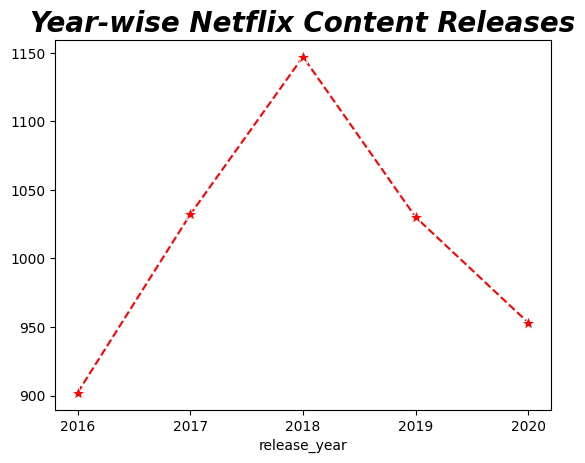

In [49]:
import matplotlib.pyplot as plt
import seaborn as sb
hrc=net["release_year"].value_counts().sort_values(ascending=False).head()
sb.lineplot(x=hrc.index,y=hrc.values,marker="*",color="red",markersize=10,linestyle="--")
plt.xticks(range(2016, 2021))
plt.title("Year-wise Netflix Content Releases",fontsize=20,fontstyle="italic",fontweight="bold")
plt.show()

Insight :
Netflix experienced a big surge in new releases between 2017 and 2019, peaking in 2018 and 2019. Release activity slowed down a bit in 2020 and 2021.

# 4. Which countries produce the most Netflix content? 

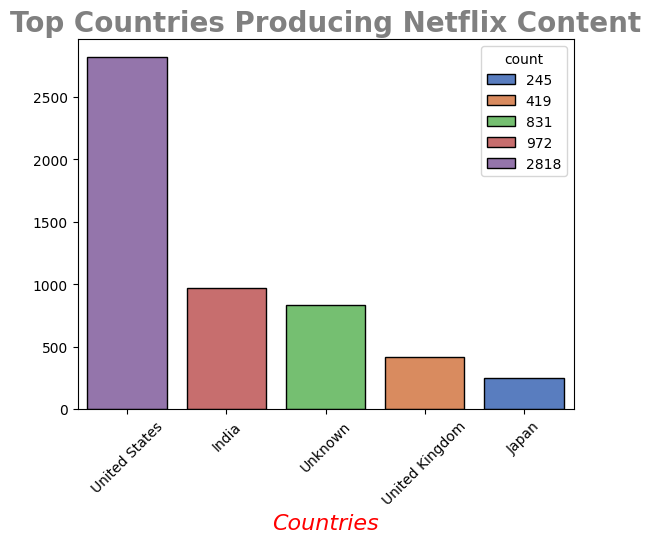

In [52]:
import matplotlib.pyplot as plt
import seaborn as sb
most_content_by_countries=net["country"].value_counts().sort_values(ascending=False).head()
sb.barplot(x=most_content_by_countries.index,y=most_content_by_countries.values,hue=most_content_by_countries,edgecolor="black",palette="muted")
plt.xticks(rotation=45)
plt.title("Top Countries Producing Netflix Content",color="gray",fontsize=20,fontweight="bold")
plt.xlabel("Countries",color="red",fontsize=16,fontstyle="italic")
plt.show()

Insight :
The United States leads as the biggest content producer on Netflix, followed by India and the United Kingdom. These three markets continue to drive much of the platform’s global appeal

# 5. How has the trend of adding new content evolved year by year? 

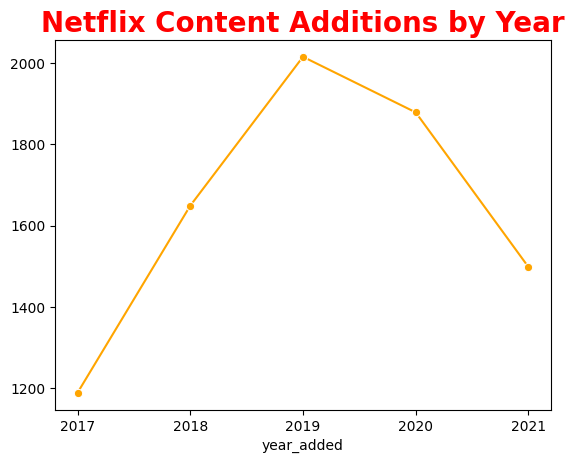

In [20]:
import matplotlib.pyplot as plt
import seaborn as sb
net["date_added"] = net['date_added'].astype(str).str.strip()
net["date_added"] = pd.to_datetime(net['date_added'], errors='coerce')
net["year_added"] = net['date_added'].dt.year
trend=net["year_added"].value_counts().sort_values(ascending=False).head()
sb.lineplot(x=trend.index,y=trend.values,marker="o",linestyle="-",color="orange")
plt.xticks(range(2017,2022))
plt.title("Netflix Content Additions by Year",fontsize=20,color="red",fontweight="bold")
plt.show()

Insight :
Netflix’s content library began growing rapidly around 2015, hitting its peak in 2019. This growth reflects the company’s shift from relying mostly on licensed titles to becoming a major creator of original ‘Netflix Originals.

# 6. Which ratings (e.g., TV-MA, PG, etc.) are most frequent on Netflix? 

Text(0.5, 1.0, 'Top Netflix Ratings by Number of Titles')

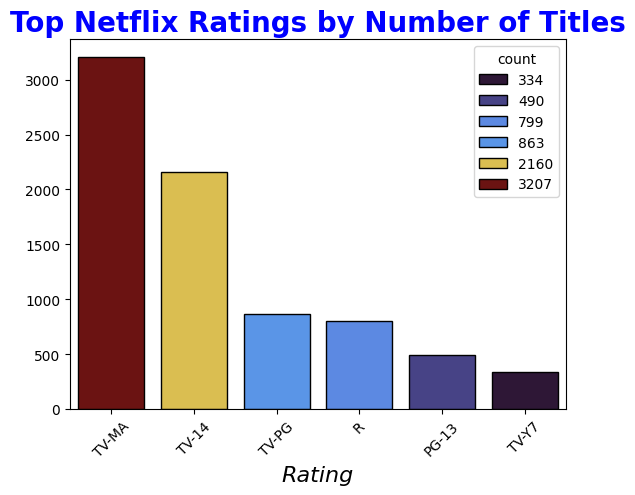

In [21]:
import matplotlib.pyplot as plt
import seaborn as sb
rating=net["rating"].value_counts().sort_values(ascending=False).head(6)
sb.barplot(x=rating.index,y=rating.values,hue=rating,palette="turbo",edgecolor="black")
plt.xticks(rotation=45)
plt.xlabel("Rating",fontsize=16,fontstyle="italic")
plt.title("Top Netflix Ratings by Number of Titles",fontsize=20,color="blue",fontweight="bold")

Insight :
Most Netflix content is rated TV-MA, with TV-14 coming in next. This shows the platform focuses largely on adult and teen audiences, rather than programming for young children

# 7. Do some countries tend to produce more mature content (TV-MA)? 

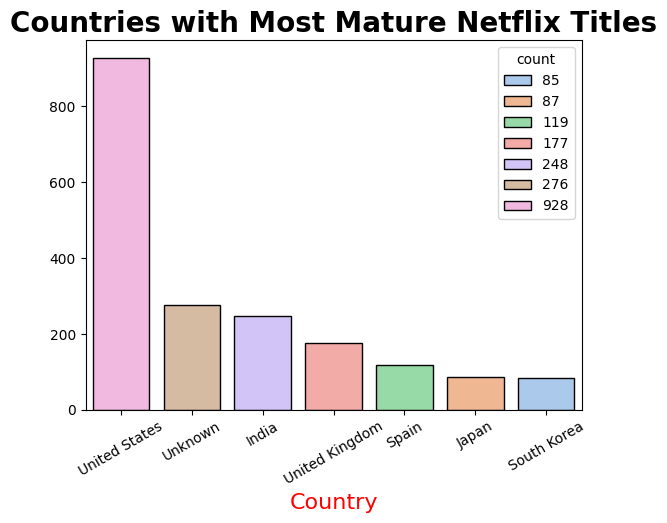

In [22]:
mature_content=net[net["rating"]=="TV-MA"]
mature_country=mature_content["country"].value_counts(ascending=False).head(7)
import matplotlib.pyplot as plt
import seaborn as sb
sb.barplot(x=mature_country.index,y=mature_country.values,hue=mature_country,edgecolor="black",palette="pastel")
plt.xticks(rotation=30)
plt.title("Countries with Most Mature Netflix Titles",fontsize=20,fontweight="bold")
plt.xlabel("Country",color="red",fontsize=16)
plt.show()



Insight :
Countries such as the United States, United Kingdom, and South Korea produce a high volume of TV-MA content. This is important for tailoring regional marketing strategies around edgy dramas and sophisticated thrillers.

# 8. Which genres are more associated with TV Shows vs Movies? 

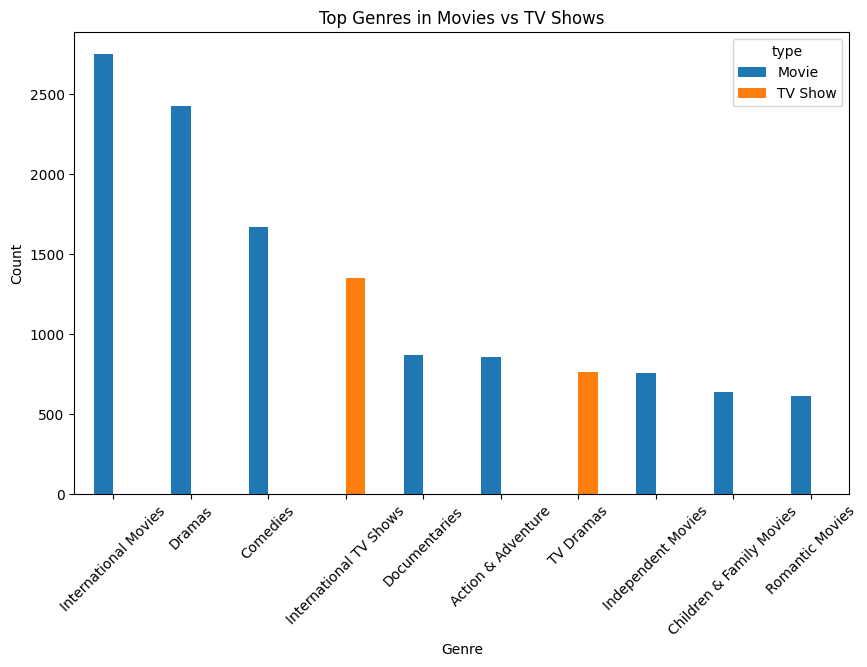

In [23]:

net_genre = net.assign(genre=net['listed_in'].str.split(', ')).explode('genre')
genre_type = net_genre.groupby(['type','genre']).size().reset_index(name='count')
genre_pivot = genre_type.pivot(index='genre', columns='type', values='count').fillna(0)
genre_pivot.sort_values(by='Movie', ascending=False).head(10)
import matplotlib.pyplot as plt
top_genres = genre_pivot.sum(axis=1).sort_values(ascending=False).head(10).index
genre_pivot.loc[top_genres].plot(kind='bar', figsize=(10,6))
plt.title("Top Genres in Movies vs TV Shows")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Insight :
Dramas and international movies lead the movie category, while international TV shows and TV dramas form the core of the TV show lineup.

# 9. Which genres dominate the U.S. vs other countries?  

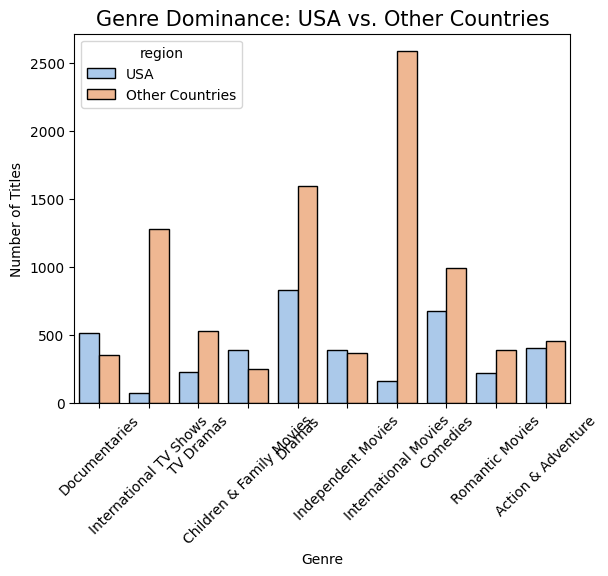

In [24]:
import matplotlib.pyplot as plt
import seaborn as sb
net['region'] = 'Other Countries'
net.loc[net['country'].str.contains('United States', na=False), 'region'] = 'USA'
net['genre_list'] = net['listed_in'].str.split(', ')
genre_df = net.explode('genre_list')
top_10_genres = genre_df['genre_list'].value_counts().head(10).index
final_df = genre_df[genre_df['genre_list'].isin(top_10_genres)]
sb.countplot(data=final_df, x="genre_list", hue="region", palette="pastel",edgecolor="black")
plt.title("Genre Dominance: USA vs. Other Countries", fontsize=15)
plt.xlabel("Genre")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()

Insight :
In the U.S., Netflix features a higher concentration of documentaries and stand-up comedy, while international markets are largely driven by romance and action titles.

# 10. What genres are most popular in the last 3 years? 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_20384\2488932064.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  recent_net['genre_list'] = recent_net['listed_in'].str.split(', ')


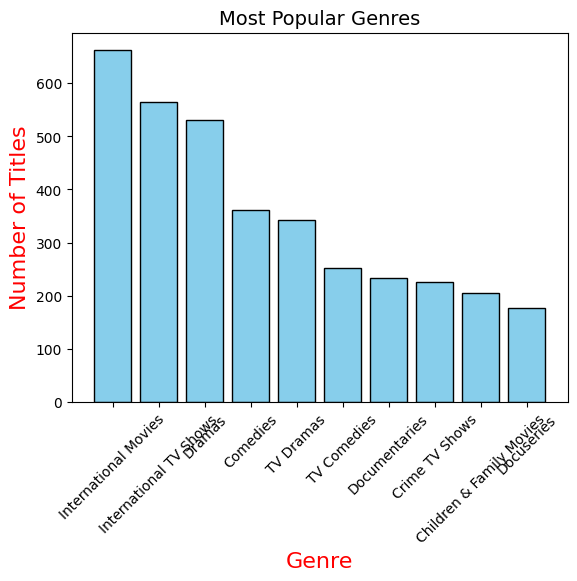

In [25]:
import matplotlib.pyplot as plt
year = net['release_year'].max()
year =year - 2
recent_net = net[net['release_year'] >=year]
recent_net['genre_list'] = recent_net['listed_in'].str.split(', ')
genre_df = recent_net.explode('genre_list')
top_10 = genre_df['genre_list'].value_counts().head(10)
plt.bar(top_10.index, top_10.values, color='skyblue', edgecolor='black')
plt.title("Most Popular Genres",fontsize=14)
plt.ylabel('Number of Titles',fontsize=16,color="red")
plt.xlabel("Genre",fontsize=16,color="red")
plt.xticks(rotation=45)
plt.show()

Insight :
Between 2019 and 2021, documentaries and international TV shows saw significant growth, reflecting a global audience that’s increasingly open to subtitles and drawn to true-crime and real-life stories.

# 11. Who are the top 10 directors with the most Netflix content? 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_20384\2519478841.py:4: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:lightgreen'` for the same effect.

  sb.barplot(x=top_directors.values,y=top_directors.index,hue=top_directors,color="lightgreen",edgecolor="black")


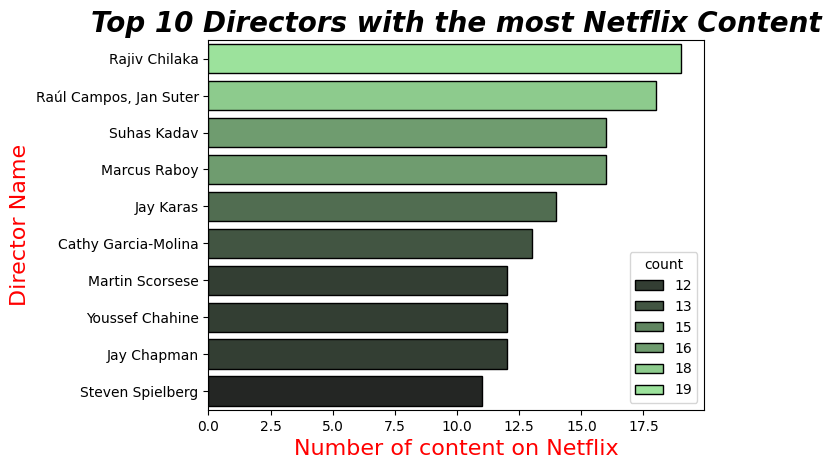

In [26]:
top_directors=net[net["director"]!="Unknown"]["director"].value_counts().sort_values(ascending=False).head(10)
import matplotlib.pyplot as plt 
import seaborn as sb
sb.barplot(x=top_directors.values,y=top_directors.index,hue=top_directors,color="lightgreen",edgecolor="black")
plt.xlabel("Number of content on Netflix",fontsize=16,color="red")
plt.ylabel("Director Name",fontsize=16,color="red")
plt.title("Top 10 Directors with the most Netflix Content",fontsize=20,fontstyle="italic",fontweight="bold")
plt.show()


Insight :
Directors such as Rajiv Chilaka, known for kids’ animation, and Jan Suter are among the most prolific on Netflix. Collaborating with high-output creators helps secure a steady stream of ‘anchor’ content for the platform

In [27]:

net["cast"].value_counts()


cast
Not Available                                                                                                                                                  825
David Attenborough                                                                                                                                              19
Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jigna Bhardwaj, Rajesh Kava, Mousam, Swapnil                                                                         14
Samuel West                                                                                                                                                     10
Jeff Dunham                                                                                                                                                      7
                                                                                                                                                              ... 
Ali Suliman, Sale

# 12. Which actors appear most frequently in Netflix shows? 

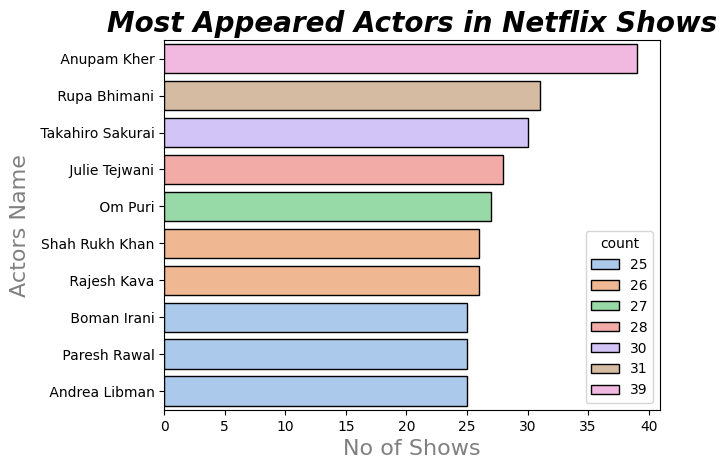

In [28]:
top_actor=net[net["cast"]!="Not Available"]["cast"].str.split(",").explode().value_counts(ascending=False).head(10)
# top_actor
import matplotlib.pyplot as plt
import seaborn as sb
sb.barplot(x=top_actor.values,y=top_actor.index,hue=top_actor,palette="pastel",edgecolor="black")
plt.xlabel("No of Shows",fontsize=16,color="gray")
plt.ylabel("Actors Name",fontsize=16,color="gray")
plt.title("Most Appeared Actors in Netflix Shows",fontsize=20,fontweight="bold",fontstyle="italic")
plt.show()

Insight :
Actors from the Indian film industry, such as Anupam Kher and Shah Rukh Khan, appear in a large number of Netflix titles. This underscores the platform’s extensive Bollywood library

In [29]:
net.groupby("director")["listed_in"].count()

director
A. L. Vijay            2
A. Raajdheep           1
A. Salaam              1
A.R. Murugadoss        2
Aadish Keluskar        1
                      ..
Çagan Irmak            1
Ísold Uggadóttir       1
Óskar Thór Axelsson    1
Ömer Faruk Sorak       2
Şenol Sönmez           2
Name: listed_in, Length: 4529, dtype: int64

In [30]:
net["director"].value_counts().sort_values(ascending=False).head()

director
Unknown                   2634
Rajiv Chilaka               19
Raúl Campos, Jan Suter      18
Suhas Kadav                 16
Marcus Raboy                16
Name: count, dtype: int64

In [31]:
top_directors = net["director"].dropna().value_counts().head(10)
print(top_directors)

director
Unknown                   2634
Rajiv Chilaka               19
Raúl Campos, Jan Suter      18
Suhas Kadav                 16
Marcus Raboy                16
Jay Karas                   14
Cathy Garcia-Molina         13
Martin Scorsese             12
Youssef Chahine             12
Jay Chapman                 12
Name: count, dtype: int64


# 13. Which director-genre pairs are most frequent? 

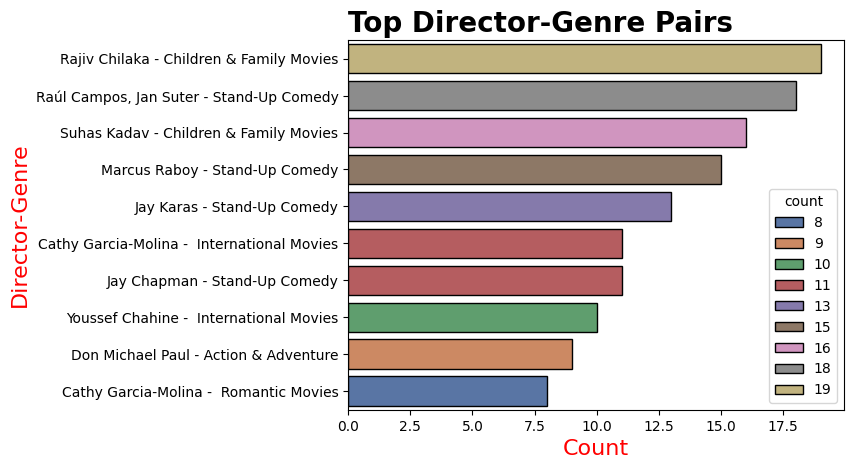

In [32]:
genres=net.assign(genre=net["listed_in"].str.split(",")).explode("genre")
genres=genres[genres["director"]!="Unknown"]
most_frequent=genres.groupby(["director","genre"]).size().reset_index(name="count")
pairs=most_frequent.sort_values(by="count",ascending=False).head(10)
import matplotlib.pyplot as plt
import seaborn as sb
pairs["label"] = pairs["director"] + " - " + pairs["genre"]
sb.barplot(y=pairs["label"],x= pairs["count"],hue=pairs["count"],palette="deep",edgecolor="black")
plt.xlabel("Count",fontsize=16,color="red")
plt.ylabel("Director-Genre",fontsize=16,color="red")
plt.title("Top Director-Genre Pairs",fontsize=20,fontweight="bold",loc="left")
plt.show()


Insight :
Netflix shows a clear pattern of pairing certain directors with specific genres, like comedy and children’s/family movies. This indicates the platform benefits from keeping proven creators within the genres where they excel

#  14. How many titles have unknown directors or cast members? 

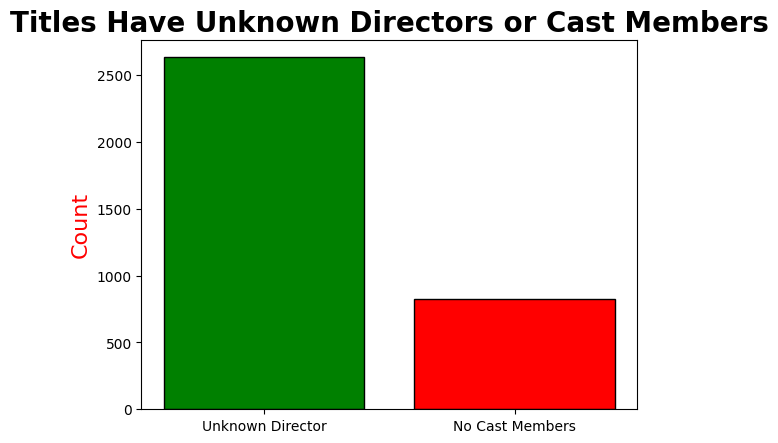

In [33]:
un_director=(net["director"]=="Unknown").sum()
no_cast=(net["cast"]=="Not Available").sum()
import matplotlib.pyplot as plt
import seaborn as sb
values=[un_director,no_cast]
labels=["Unknown Director","No Cast Members"]
plt.bar(labels,values,color=["green","red"],edgecolor="black")
plt.ylabel("Count",fontsize=16,color="red")
plt.title("Titles Have Unknown Directors or Cast Members",fontsize=20,fontweight="bold")
plt.show()

Insight :
Data Gaps: A significant portion of the data (roughly 30%) had missing directors. Filling these gaps is essential for better recommendation algorithms and talent tracking.

In [34]:
net.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      8807 non-null   object        
 4   cast          8807 non-null   object        
 5   country       8807 non-null   object        
 6   date_added    8797 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8807 non-null   object        
 9   duration      8807 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
 12  year_added    8797 non-null   float64       
 13  region        8807 non-null   object        
 14  genre_list    8807 non-null   object        
dtypes: datetime64[ns](1), float64(1), int6

In [35]:
net["duration"].isnull().sum()

np.int64(0)

In [36]:
net["type"].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

#  15. What is the average duration of Movies on Netflix? 

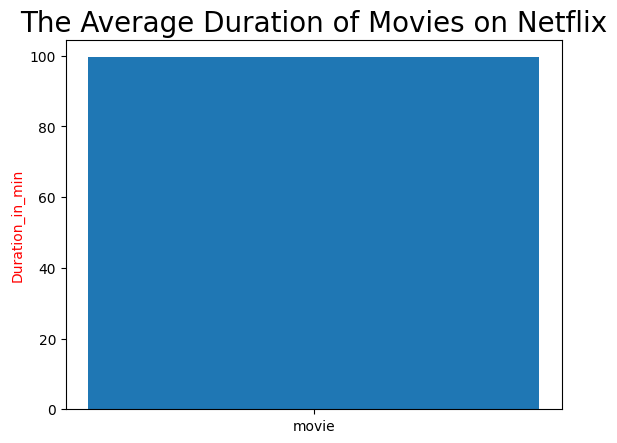

In [37]:
movie=net[net["type"]=="Movie"].copy()
movie["duration"]=movie["duration"].str.replace("min"," ")
movie["duration"]=movie["duration"].astype(float)
avg_duraction=movie["duration"].mean()
import matplotlib.pyplot as plt
import seaborn as sb
plt.bar(["movie"],[avg_duraction])
plt.ylabel("Duration_in_min",color="red")
plt.title("The Average Duration of Movies on Netflix",fontsize=20)
plt.show()

Insight:
Netflix movies typically run between 90 and 110 minutes. This ‘sweet spot’ seems ideal for keeping viewers engaged without feeling too long.

# 16. What’s the most common number of seasons for TV shows? 

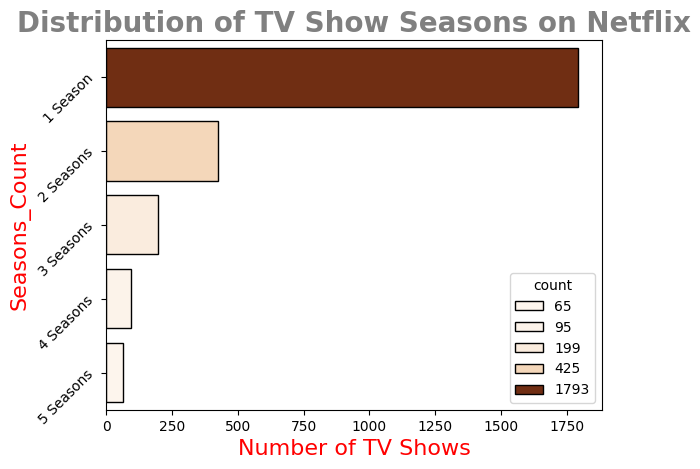

In [38]:
tv_show=net[net["type"]=="TV Show"]
common_season=tv_show["duration"].value_counts().sort_values(ascending=False).head()
import matplotlib.pyplot as plt
import seaborn as sb
sb.barplot(x=common_season.values,y=common_season.index,hue=common_season,palette="Oranges",edgecolor="black")
plt.xlabel("Number of TV Shows",color="red",fontsize=16)
plt.ylabel("Seasons_Count",color="red",fontsize=16)
plt.title("Distribution of TV Show Seasons on Netflix",fontsize=20,color="gray",fontweight="bold")
plt.yticks(rotation=45)
plt.show()

Insight :
Most Netflix TV shows have just one season, highlighting a ‘one-and-done’ trend. Many are either limited series or get canceled if they don’t achieve quick success

# 17. Is there a trend in movie durations over the years? 

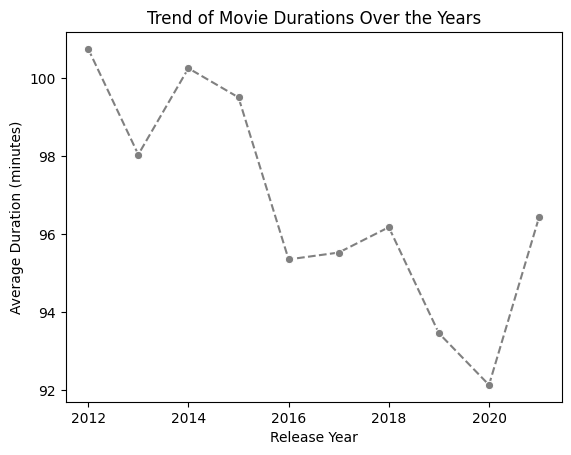

In [39]:
mov = net[net["type"]=="Movie"].copy()
mov["duration"]=mov["duration"].str.replace("min","").str.strip()
mov["duration"]=pd.to_numeric(mov["duration"],errors="coerce")
year=mov.groupby("release_year")["duration"].mean().sort_index(ascending=False)
year=year.head(10)
import matplotlib.pyplot as plt
import seaborn as sb
import matplotlib.pyplot as plt
sb.lineplot(x=year.index,y=year.values,marker="o",color="gray",linestyle="--")
plt.xlabel("Release Year")
plt.ylabel("Average Duration (minutes)")
plt.title("Trend of Movie Durations Over the Years")
plt.show()



Insight :
Over the years, Netflix movies have been trending slightly shorter, edging closer to the 90-minute mark. This reflects audiences’ shorter attention spans compared to the longer, 2-hour-plus epics of the early 2000s

# 18.In which months does Netflix add the most content? 

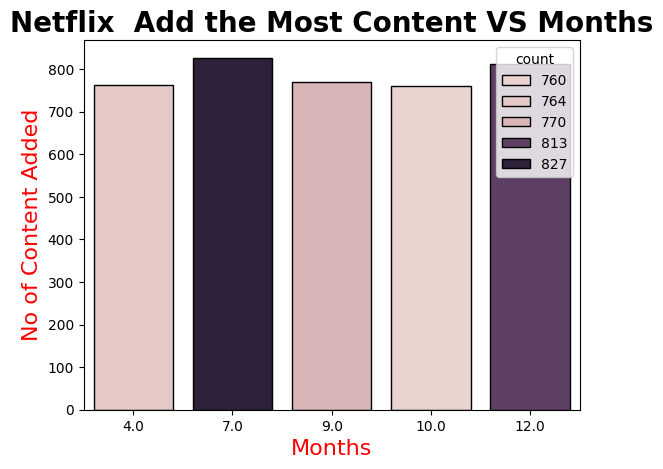

In [40]:
net["months"]=net["date_added"].dt.month
most_content=net["months"].value_counts().sort_values(ascending=False).head()
import matplotlib.pyplot as plt
import seaborn as sb
most_content
orders=["April","July","September","October","December"]
sb.barplot(x=most_content.index,y=most_content.values,hue=most_content,edgecolor="black")
plt.xlabel("Months",color="red",fontsize=16)
plt.ylabel("No of Content Added",color="red",fontsize=16)
plt.title("Netflix  Add the Most Content VS Months",fontweight="bold",fontsize=20)
plt.show()

Insight :
Netflix tends to add the most content in July, December, and January, which aligns with summer and winter holiday periods when global viewership is at its highest.

# 19. How does the genre distribution vary across different years? 

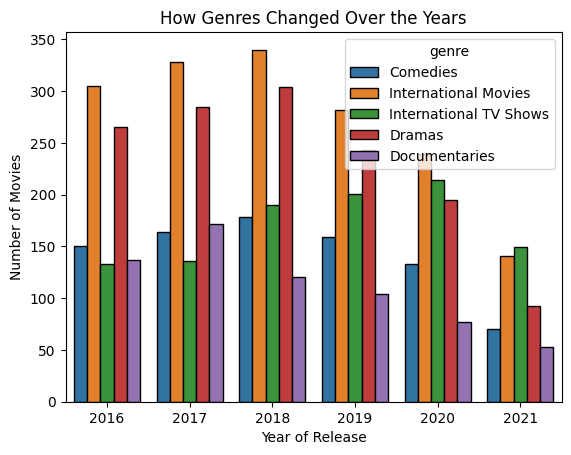

In [41]:
import matplotlib.pyplot as plt
import seaborn as sb
net['genre'] = net['listed_in'].str.split(', ')
genre_df = net.explode('genre')
top = genre_df['genre'].value_counts().head(5).index
recent_data = genre_df[(genre_df['genre'].isin(top)) & (genre_df['release_year'] > 2015)]
sb.countplot(data=recent_data, x='release_year', hue='genre',edgecolor="black")
plt.title('How Genres Changed Over the Years')
plt.xlabel('Year of Release')
plt.ylabel('Number of Movies')
plt.show()

Insight :
Over time, Netflix has evolved from mainly hosting comedies and dramas to placing a stronger focus on original documentaries and reality TV

# 20. Which countries produce the most content in each genre? 

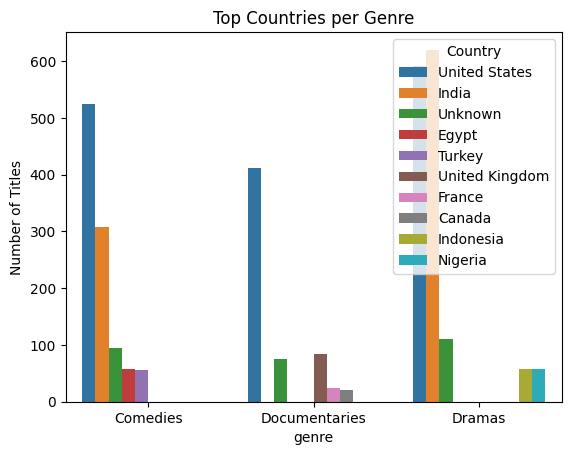

In [42]:
genre_country = net.assign(genre=net["listed_in"].str.split(",")).explode("genre")
genre_country["genre"] = genre_country["genre"].str.strip()
country_genre = genre_country.groupby(["country","genre"]).size().reset_index(name="count")
top_country_genre = country_genre.sort_values(["genre","count"], ascending=[True,False])
top_country_genre = top_country_genre.groupby("genre").head(5)
top_country_genre.head()
import matplotlib.pyplot as plt
import seaborn as sb
target_genres = ['Dramas', 'Comedies', 'Documentaries']
sub_set = top_country_genre[top_country_genre['genre'].isin(target_genres)]
sb.barplot(data=sub_set, x='genre', y='count', hue='country')
plt.title("Top Countries per Genre")
plt.ylabel("Number of Titles")
plt.legend(title="Country", loc='upper right')
plt.show()

Insight :
India produces a large number of dramas and comedies, while the United States leads in documentaries and horror. This highlights an opportunity for Netflix to focus on geo-targeted licensing by sourcing content that each region does bes

In [43]:
net.to_excel("net.xlsx")